In [1]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd

In [2]:
def U_D(gamma_0,gamma_1,delta=0.5):
    return (1-delta)*np.sum(gamma_1) - (gamma_1[0]-gamma_0[0])**2 - (gamma_1[1]-gamma_0[1])**2

def U_G(gamma_0,gamma_1,delta=0.5):
    return delta*np.sum(gamma_1) - (gamma_0[0])**2 - (gamma_0[1])**2

def gamma_1(gamma_0,threshold,delta=0.5):
    alpha_1 = gamma_0[0] + (1-delta)/2
    beta_1 = np.max([gamma_0[1]+(1-delta)/2, threshold])
    return np.array([alpha_1,beta_1])

def lambda_candidates(delta,threshold):
    A = -0.5*(1-delta)**2
    #print(A)
    B = 0.25*(1-delta**2)+threshold*(1-delta)
    #print(B)
    root_list = np.array([A, -2*A+B, A-2*B, B-threshold**2])
    #print(root_list)
    candidates = np.roots(root_list)
    return candidates#candidates.real[abs(candidates.imag)<1e-5]

def gamma_0_squeeze_candidates(delta,threshold,Gthreshold=0):
    lambda_tries = lambda_candidates(delta,threshold)
    feasible_strategies = []
    for l in lambda_tries:
        #if l==1:
        #    continue
        alpha_0 = 0.5*(delta-l*(1-delta))
        beta_0 = l*threshold/(l-1)
        g0 = np.array([alpha_0,beta_0])
        if alpha_0<0 or beta_0<Gthreshold:
            continue
        g1 = gamma_1(g0,threshold,delta=delta)
        ug = U_G(g0,g1,delta=delta)
        ud = U_D(g0,g1,delta=delta)
        if ug<0 or ud+1e-5<0:
            continue
        feasible_strategies = feasible_strategies+[g0]
    if len(feasible_strategies) == 0:
        #print("WARNING: No feasible strategies on the U_D=0 constraint, ",threshold, lambda_tries)
        True
    elif len(feasible_strategies) > 1:
        #print("WARNING: Multiple feasible strategies on the U_D=0 constraint. This is weird.")
        True
    return feasible_strategies

def G_strategy_all_candidates(delta,threshold,Gthreshold=0):
    candidates = []
    candidates = candidates + [np.array([0,Gthreshold])]
    candidates = candidates + [np.array([delta/2,delta/2])]
    candidates = candidates + [np.array([delta/2,Gthreshold])]
    #candidates = candidates + [np.array([delta/2,t-(1-delta)/2])]
    #candidates = candidates + [np.array([0,delta/2])]
    #candidates = candidates + [np.array([0,t-(1-delta)/2])]
    candidates = candidates + gamma_0_squeeze_candidates(delta,threshold)
    
    #which does the best?
    U_Gs=[]
    U_Ds = []
    ug_max = -1
    final_strategy = np.array([-1,-1])
    for g0 in candidates:
        g1 = gamma_1(g0,threshold,delta=delta)
        if g1[0]==0 and g1[1]==0:
            continue
        ug = U_G(g0,g1,delta=delta)
        ud = U_D(g0,g1,delta=delta)
        if ug > ug_max and ud+1e-5>=0 and g1[1]>=threshold and g0[0]>=0 and g0[1]>=Gthreshold:
            final_strategy = g0
            ug_max = ug
    return final_strategy

In [3]:
G_strategy_all_candidates(0.5,2,0)

array([0.44139111, 0.86721778])

In [4]:
#gamma_0_squeeze_candidates(0.5,.751)
gamma_0_squeeze_candidates(0.5,1.2,.2)

[array([0.32980887, 0.29038226])]

In [5]:
#Start with a simple example.
#The G threshold is 0 and the D threshold is 0. Delta is 0.5.
delta=0.5
t=0
gt=.5

def strategies(delta,t,gt):    
    alpha_0,beta_0 = G_strategy_all_candidates(delta,t,gt)
    alpha_1,beta_1 = gamma_1([alpha_0,beta_0],t,delta)
    return alpha_0,beta_0,alpha_1,beta_1


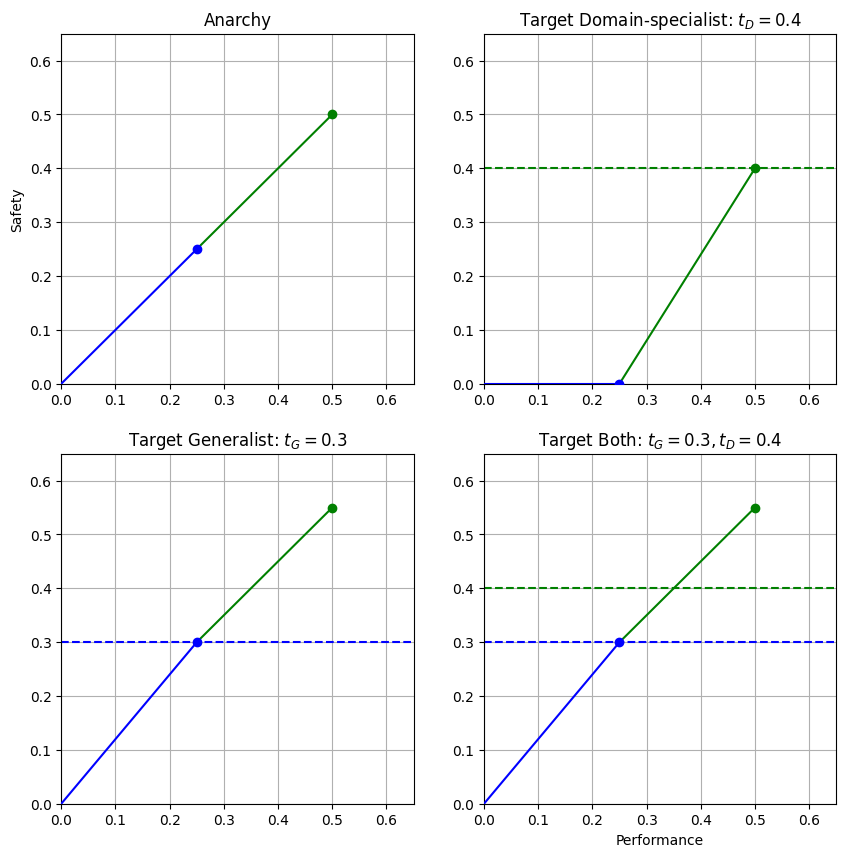

In [6]:
fig, ax = plt.subplots(2,2,figsize=[10,10])

td=0
tg=0
alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[0,0].set_title("Anarchy")
ax[0,0].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[0,0].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[0,0].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[0,0].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[0,0].set_xlim([0,.65])
ax[0,0].set_ylim([0,.65])
ax[0,0].grid()
ax[0,0].set_xticks(np.linspace(0,.6,7))
ax[0,0].set_yticks(np.linspace(0,.6,7))
ax[0,0].set_ylabel('Safety')

td=.4
tg=0
alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[0,1].set_title("Target Domain-specialist: $t_D = %0.1f$" % td)
ax[0,1].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[0,1].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[0,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[0,1].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[0,1].axhline(td,c='g',ls='--')
ax[0,1].set_xlim([0,.65])
ax[0,1].set_ylim([0,.65])
ax[0,1].grid()
ax[0,1].set_xticks(np.linspace(0,.6,7))
ax[0,1].set_yticks(np.linspace(0,.6,7))

td=0
tg=.3
alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[1,0].set_title("Target Generalist: $t_G = %0.1f$" % tg)
ax[1,0].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[1,0].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[1,0].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[1,0].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[1,0].axhline(tg,c='b',ls='--')
ax[1,0].set_xlim([0,.65])
ax[1,0].set_ylim([0,.65])
ax[1,0].grid()
ax[1,0].set_xticks(np.linspace(0,.6,7))
ax[1,0].set_yticks(np.linspace(0,.6,7))

td=.4
tg=.3
alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[1,1].set_title("Target Both: $t_G = %0.1f, t_D = %0.1f$" % (tg,td))
ax[1,1].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[1,1].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[1,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[1,1].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[1,1].axhline(td,c='g',ls='--')
ax[1,1].axhline(tg,c='b',ls='--')
ax[1,1].set_xlim([0,.65])
ax[1,1].set_ylim([0,.65])
ax[1,1].grid(zorder=-10)
ax[1,1].set_xticks(np.linspace(0,.6,7))
ax[1,1].set_yticks(np.linspace(0,.6,7))
ax[1,1].set_xlabel('Performance')

plt.savefig('teaser_figure_fine_tuning_regulation.png',bbox_inches='tight',dpi=300)

In [7]:
#For a range of thresholds and deltas...
thresholds = np.linspace(0,1,2)
Gthresholds = np.linspace(0,.5,2)
deltas = np.linspace(0,1,201)

In [8]:
for t in thresholds:
    G_strategies = []
    D_strategies = []
    U_Gs = []
    U_Ds = []
    for delta in deltas:
        g_0 = G_strategy_all_candidates(delta,t)
        if g_0[0] == -1:
            G_strategies = G_strategies + [np.array([0,0])]
            D_strategies = D_strategies + [np.array([0,0])]
            U_Gs = U_Gs + [0]
            U_Ds = U_Ds + [0]
            continue
        g_1 = gamma_1(gamma_0=g_0,threshold=t,delta=delta)
        G_strategies = G_strategies + [g_0]
        D_strategies = D_strategies + [g_1]
        U_Gs = U_Gs + [U_G(g_0,g_1,delta=delta)]
        U_Ds = U_Ds + [U_D(g_0,g_1,delta=delta)]
    G_strategies_all = G_strategies_all + [G_strategies]
    D_strategies_all = D_strategies_all + [D_strategies]
    U_Gs_all = U_Gs_all + [U_Gs]
    U_Ds_all = U_Ds_all + [U_Ds]
    

NameError: name 'G_strategies_all' is not defined

# With multiple specialists

In [9]:
def U_D_i(gamma_0,gamma_1,C_i, delta=0.5):
    return (1-delta)*np.sum(gamma_1) - C_i[0,0]*(gamma_1[0]-gamma_0[0])**2 - C_i[1,1]*(gamma_1[1]-gamma_0[1])**2

def U_G(gamma_0,gamma_list,delta=0.5):
    revenue = np.sum([delta*np.sum(gamma_list[i]) for i in range(len(gamma_list))])
    return revenue - C_0[0,0]*(gamma_0[0])**2 - C_0[1,1]*(gamma_0[1])**2

def gamma_i(gamma_0,threshold, C_i, r, delta=0.5):
    #alpha_1 = gamma_0 + (1-delta)/2 * np.linalg.dot(np.linalg.inv(C),r)
    #beta_1 = np.max([gamma_0[1]+(1-delta)/2, threshold])
    candidate_anarchy =  gamma_0 + (1-delta)/2 * np.dot(np.linalg.inv(C_i),r) #np.array([alpha_1,beta_1])
    if candidate_anarchy[1]<threshold:
        print(U_D_i(gamma_0,np.array([candidate_anarchy[0],threshold]),C_i,delta=delta))
        return np.array([candidate_anarchy[0],threshold])
    print(U_D_i(gamma_0,candidate_anarchy,C_i,delta=delta))
    return candidate_anarchy

def gamma_0(threshold, C_0, r, delta=0.5,n=1,gt=0):
    #alpha_1 = gamma_0 + (1-delta)/2 * np.linalg.dot(np.linalg.inv(C),r)
    #beta_1 = np.max([gamma_0[1]+(1-delta)/2, threshold])
    candidate =  n*(delta)/2 * np.dot(np.linalg.inv(C_0),r) #np.array([alpha_1,beta_1])
    #if candidate_anarchy[1]<threshold:
    #    return np.array([candidate_anarchy[0],threshold])
    if threshold>0.1:
        candidate = np.array([candidate[0],0])
    if candidate[1]<gt:
        return np.array([candidate[0],gt])
    return candidate

In [10]:
#UG = sum delta_i r gamma_i - C_0gamma_0^2
#dUG/dgamma0 = sum delta_i r  - 2c_0 gamma_0
#gamma_0 = sum delta_i r / (2c_0)

In [11]:
C_0 = np.array([[1,0],[0,1]])
factor=2.4
C_1=np.array([[1/factor,0],[0,1/factor]])
#C_2=np.array([[1.1/factor,0],[0,.8/factor]])
#C_3=np.array([[.9/factor,0],[0,1.3/factor]])
C_2=np.array([[1.8/factor,0],[0,.8/factor]])
C_3=np.array([[.9/factor,0],[0,1.9/factor]])

r = np.array([1,1])
g0 = np.array([.5,.5])

t = 0

In [12]:
def strategies_multispecialist(C_0,C_1,C_2,C_3,r,t,gt,delta=0.5,n=3):
    alpha_0,beta_0 = gamma_0(t,C_0,r,n=3,gt=gt)
    alpha_1,beta_1 = gamma_i([alpha_0,beta_0],t, C_1, r, delta=0.5)
    alpha_2,beta_2 = gamma_i([alpha_0,beta_0],t, C_2, r, delta=0.5)
    alpha_3,beta_3 = gamma_i([alpha_0,beta_0],t, C_3, r, delta=0.5)
    return alpha_0,beta_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3

In [13]:
gamma_i(g0,.7, C_3, r,0.5)

0.7456140350877193


array([1.16666667, 0.81578947])

In [14]:
gamma_0(.7, C, r,0.5,n=3)

NameError: name 'C' is not defined

1.0499999999999998
1.0208333333333333
0.9956140350877194
1.075
1.0458333333333332
1.0206140350877195
0.6083333333333332
0.6249999999999999
0.2500000000000001
1.075
1.0458333333333332
1.0150000000000001


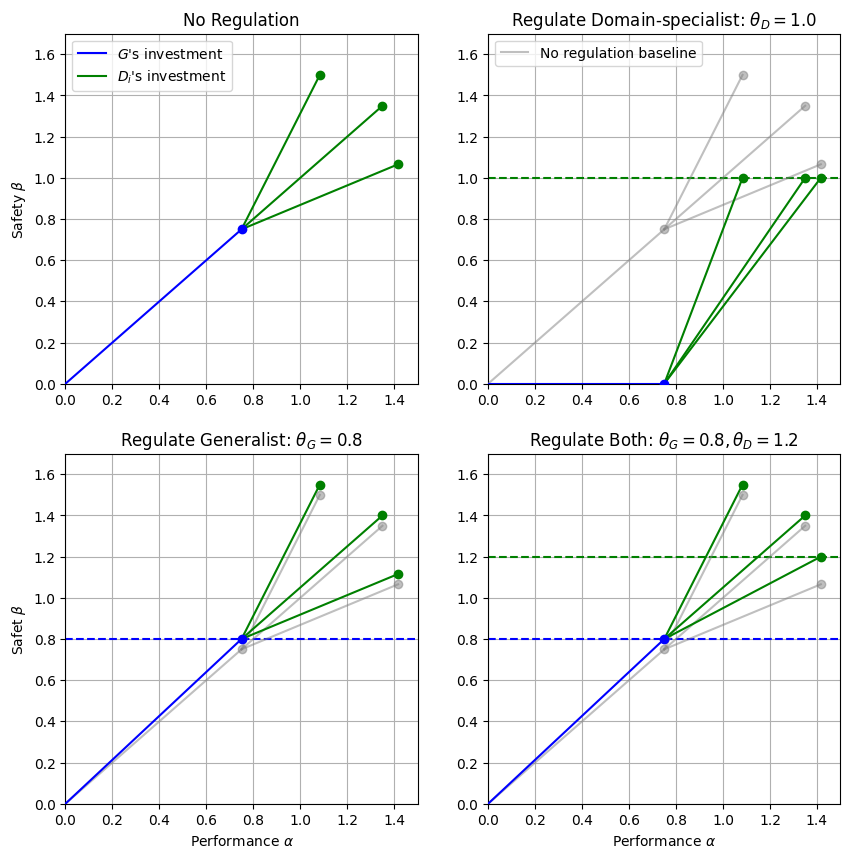

In [30]:
fig, ax = plt.subplots(2,2,figsize=[10,10])

td=0
tg=0
alpha_0,beta_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3 = strategies_multispecialist(C_0,C_1,C_2,C_3,r,td,tg,delta=0.5,n=3)
#alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[0,0].set_title("No Regulation")
ax[0,0].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10, label = '$G$\'s investment')
ax[0,0].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[0,0].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10, label = '$D_i$\'s investment')
ax[0,0].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[0,0].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='g',zorder=10)
ax[0,0].scatter(alpha_2,beta_2,c='g',zorder=100)
ax[0,0].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='g',zorder=10)
ax[0,0].scatter(alpha_3,beta_3,c='g',zorder=100)
ax[0,0].set_xlim([0,1.5])
ax[0,0].set_ylim([0,1.7])
ax[0,0].grid()
#ax[0,0].set_xticks(np.linspace(0,1,11))
#ax[0,0].set_yticks(np.linspace(0,1,11))
ax[0,0].set_ylabel('Safety $\\beta$')

ax[0,0]. legend(loc='upper left')


ax[1,0].plot([0,alpha_0],[0,beta_0],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,0].scatter(alpha_0,beta_0,c='gray', alpha=0.5,zorder=100)
ax[1,0].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,0].scatter(alpha_1,beta_1,c='gray', alpha=0.5,zorder=100)
ax[1,0].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,0].scatter(alpha_2,beta_2,c='gray', alpha=0.5,zorder=100)
ax[1,0].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,0].scatter(alpha_3,beta_3,c='gray', alpha=0.5,zorder=100)

ax[0,1].plot([0,alpha_0],[0,beta_0],ls='-',c='gray', alpha=0.5,zorder=10, label = 'No regulation baseline')
ax[0,1].scatter(alpha_0,beta_0,c='gray', alpha=0.5,zorder=100)
ax[0,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='gray', alpha=0.5,zorder=10)
ax[0,1].scatter(alpha_1,beta_1,c='gray', alpha=0.5,zorder=100)
ax[0,1].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='gray', alpha=0.5,zorder=10)
ax[0,1].scatter(alpha_2,beta_2,c='gray', alpha=0.5,zorder=100)
ax[0,1].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='gray', alpha=0.5,zorder=10)
ax[0,1].scatter(alpha_3,beta_3,c='gray', alpha=0.5,zorder=100)

ax[1,1].plot([0,alpha_0],[0,beta_0],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,1].scatter(alpha_0,beta_0,c='gray', alpha=0.5,zorder=100)
ax[1,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,1].scatter(alpha_1,beta_1,c='gray', alpha=0.5,zorder=100)
ax[1,1].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,1].scatter(alpha_2,beta_2,c='gray', alpha=0.5,zorder=100)
ax[1,1].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='gray', alpha=0.5,zorder=10)
ax[1,1].scatter(alpha_3,beta_3,c='gray', alpha=0.5,zorder=100)

td=0
tg=.8
alpha_0,beta_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3 = strategies_multispecialist(C_0,C_1,C_2,C_3,r,td,tg,delta=0.5,n=3)
#alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[1,0].set_title("Regulate Generalist: $\\theta_G = %0.1f$" % tg)
ax[1,0].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[1,0].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[1,0].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[1,0].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[1,0].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='g',zorder=10)
ax[1,0].scatter(alpha_2,beta_2,c='g',zorder=100)
ax[1,0].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='g',zorder=10)
ax[1,0].scatter(alpha_3,beta_3,c='g',zorder=100)
ax[1,0].set_xlim([0,1.5])
ax[1,0].set_ylim([0,1.7])
ax[1,0].grid()
#ax[0,0].set_xticks(np.linspace(0,1,11))
#ax[0,0].set_yticks(np.linspace(0,1,11))
ax[1,0].set_ylabel('Safet $\\beta$')
ax[1,0].axhline(tg,c='b',ls='--')
ax[1,0].set_xlabel("Performance $\\alpha$")

td=1
tg=0
alpha_0,beta_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3 = strategies_multispecialist(C_0,C_1,C_2,C_3,r,td,tg,delta=0.5,n=3)
#alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[0,1].set_title("Regulate Domain-specialist: $\\theta_D = %0.1f$" % td)
ax[0,1].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[0,1].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[0,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[0,1].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[0,1].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='g',zorder=10)
ax[0,1].scatter(alpha_2,beta_2,c='g',zorder=100)
ax[0,1].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='g',zorder=10)
ax[0,1].scatter(alpha_3,beta_3,c='g',zorder=100)
ax[0,1].set_xlim([0,1.5])
ax[0,1].set_ylim([0,1.7])
ax[0,1].grid()
#ax[0,0].set_xticks(np.linspace(0,1,11))
#ax[0,0].set_yticks(np.linspace(0,1,11))
#ax[0,1].set_ylabel('Safety')
ax[0,1].axhline(td,c='g',ls='--')
ax[0,1].legend(loc='upper left')


td=1.2
tg=.8
alpha_0,beta_0,alpha_1,beta_1,alpha_2,beta_2,alpha_3,beta_3 = strategies_multispecialist(C_0,C_1,C_2,C_3,r,td,tg,delta=0.5,n=3)
#alpha_0,beta_0,alpha_1,beta_1 = strategies(0.5,td,tg)
ax[1,1].set_title("Regulate Both: $\\theta_G = %0.1f, \\theta_D = %0.1f$" % (tg,td))
ax[1,1].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
ax[1,1].scatter(alpha_0,beta_0,c='b',zorder=100)
ax[1,1].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
ax[1,1].scatter(alpha_1,beta_1,c='g',zorder=100)
ax[1,1].plot([alpha_0,alpha_2],[beta_0,beta_2],ls='-',c='g',zorder=10)
ax[1,1].scatter(alpha_2,beta_2,c='g',zorder=100)
ax[1,1].plot([alpha_0,alpha_3],[beta_0,beta_3],ls='-',c='g',zorder=10)
ax[1,1].scatter(alpha_3,beta_3,c='g',zorder=100)
ax[1,1].set_xlim([0,1.5])
ax[1,1].set_ylim([0,1.7])
ax[1,1].grid()
#ax[0,0].set_xticks(np.linspace(0,1,11))
#ax[0,0].set_yticks(np.linspace(0,1,11))
#ax[1,1].set_ylabel('Safety')
ax[1,1].axhline(td,c='g',ls='--')
ax[1,1].axhline(tg,c='b',ls='--')
ax[1,1].set_xlabel("Performance $\\alpha$")

plt.savefig('teaser_figure_june9.png',bbox_inches='tight',dpi=300)


In [ ]:

def lambda_candidates(delta,threshold):
    A = -0.5*(1-delta)**2
    #print(A)
    B = 0.25*(1-delta**2)+threshold*(1-delta)
    #print(B)
    root_list = np.array([A, -2*A+B, A-2*B, B-threshold**2])
    #print(root_list)
    candidates = np.roots(root_list)
    return candidates#candidates.real[abs(candidates.imag)<1e-5]

def gamma_0_squeeze_candidates(delta,threshold,Gthreshold=0):
    lambda_tries = lambda_candidates(delta,threshold)
    feasible_strategies = []
    for l in lambda_tries:
        #if l==1:
        #    continue
        alpha_0 = 0.5*(delta-l*(1-delta))
        beta_0 = l*threshold/(l-1)
        g0 = np.array([alpha_0,beta_0])
        if alpha_0<0 or beta_0<Gthreshold:
            continue
        g1 = gamma_1(g0,threshold,delta=delta)
        ug = U_G(g0,g1,delta=delta)
        ud = U_D(g0,g1,delta=delta)
        if ug<0 or ud+1e-5<0:
            continue
        feasible_strategies = feasible_strategies+[g0]
    if len(feasible_strategies) == 0:
        #print("WARNING: No feasible strategies on the U_D=0 constraint, ",threshold, lambda_tries)
        True
    elif len(feasible_strategies) > 1:
        #print("WARNING: Multiple feasible strategies on the U_D=0 constraint. This is weird.")
        True
    return feasible_strategies

def G_strategy_all_candidates(delta,threshold,Gthreshold=0):
    candidates = []
    candidates = candidates + [np.array([0,Gthreshold])]
    candidates = candidates + [np.array([delta/2,delta/2])]
    candidates = candidates + [np.array([delta/2,Gthreshold])]
    #candidates = candidates + [np.array([delta/2,t-(1-delta)/2])]
    #candidates = candidates + [np.array([0,delta/2])]
    #candidates = candidates + [np.array([0,t-(1-delta)/2])]
    candidates = candidates + gamma_0_squeeze_candidates(delta,threshold)
    
    #which does the best?
    U_Gs=[]
    U_Ds = []
    ug_max = -1
    final_strategy = np.array([-1,-1])
    for g0 in candidates:
        g1 = gamma_1(g0,threshold,delta=delta)
        if g1[0]==0 and g1[1]==0:
            continue
        ug = U_G(g0,g1,delta=delta)
        ud = U_D(g0,g1,delta=delta)
        if ug > ug_max and ud+1e-5>=0 and g1[1]>=threshold and g0[0]>=0 and g0[1]>=Gthreshold:
            final_strategy = g0
            ug_max = ug
    return final_strategy